**Instruções gerais:** Sua submissão <u>deve</u> conter:
1. Um "ipynb" com seu código e as soluções dos problemas
2. Uma versão pdf do ipynb

Caso você opte por resolver as questões de "papel e caneta" em um editor de $\LaTeX$ externo, o inclua no final da versão pdf do 'ipynb'--- submetendo um <u>único pdf</u>.

In [ ]:
import numpy as np
from sklearn.neighbors import KNeighborsRegressor
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.datasets import fetch_california_housing
from collections import Counter


# Cross-validation

**1.** O código abaixo carrega o banco de dados *California housing*. Divida o banco de dados em treino, teste e validação. Use o conjunto de validação para escolher o coeficiente de regularização $c$ para um modelo de regressão linear com penalização $L_2$. Use a fórmula analítica para estimar os pesos do modelo de regressão. Plote os MSE no conjunto de trieno e validação em função de $c$. Comente o resultado. Avalie a performance do modelo ótimo no conjunto de teste e também comente.

In [ ]:
SEED = 42
np.random.seed(SEED)

X, y = fetch_california_housing(return_X_y=True)

In [ ]:
x_treino, Xtest, y_treino, ytest = train_test_split(X, y, test_size=0.2, random_state=SEED)
x_treino, x_val, y_treino, y_val = train_test_split(x_treino, y_treino, test_size=0.2, random_state=SEED)

x_treino = np.hstack((x_treino, np.ones((x_treino.shape[0], 1))))
x_val = np.hstack((x_val, np.ones((x_val.shape[0], 1))))
Xtest = np.hstack((Xtest, np.ones((Xtest.shape[0], 1))))


Acima fizemos a etapa da divisão do banco de dados. Com isso podemos utilizar esse último conjunto para escolher o coeficiente de regularização $c$ para um modelo de regressão linear com penalização $L_2$. Para isso, vamos utilizar a fórmula analítica para estimar os pesos do modelo de regressão.

Queremos uma função que recebe os dados de treino e de validação e retorna o melhor valor de $c$ para o caso de uma regressão linear de forma fechada. A penalização utilizada é a $L_2$:

$$\text{pesos} = (X^T X + cI)^{-1} X^Ty$$

In [ ]:
valores_c = np.logspace(-4, 2, 20)

def melhor_c(x_treino, y_treino, x_val, y_val):
    MSEs = []

    for c in valores_c:
        # estimamos os pesos da regressão linear de forma fechada
        weights = np.linalg.inv(x_treino.T @ x_treino + c * np.eye(x_treino.shape[1])) @ x_treino.T @ y_treino

        # obtemos a predição
        ypred = x_val @ weights

        # calcula o MSE
        MSE = np.mean((ypred - y_val) ** 2)
        MSEs.append(MSE)

    best_c = valores_c[np.argmin(MSEs)]
    return best_c, MSEs, valores_c

best_c, MSEs, valores_c = melhor_c(x_treino, y_treino, x_val, y_val)
print(f'O melhor valor de c dentro da lista \n\n {valores_c}\n\n é: {best_c}')

O melhor valor de c dentro da lista 

 [1.00000000e-04 2.06913808e-04 4.28133240e-04 8.85866790e-04
 1.83298071e-03 3.79269019e-03 7.84759970e-03 1.62377674e-02
 3.35981829e-02 6.95192796e-02 1.43844989e-01 2.97635144e-01
 6.15848211e-01 1.27427499e+00 2.63665090e+00 5.45559478e+00
 1.12883789e+01 2.33572147e+01 4.83293024e+01 1.00000000e+02]

 é: 0.0001


Encontramos o melhor valor de  c , dentro da lista pré definida. Para que esse resultado seja mais claro, vamos plotar os MSE no conjunto de treino e de validação em função de  c :

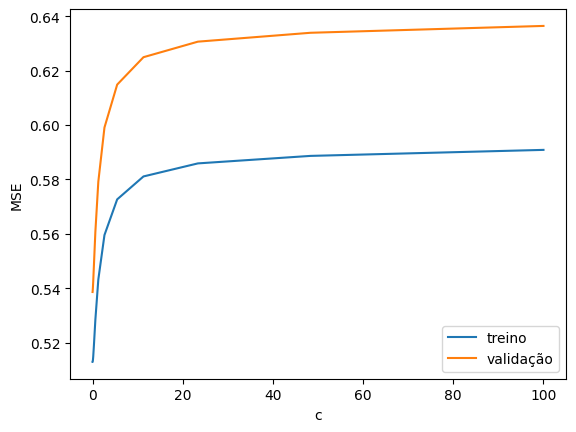

In [ ]:
_, MSEs_treino, _ = melhor_c(x_treino, y_treino, x_treino, y_treino)
_, MSEs_val, _ = melhor_c(x_treino, y_treino, x_val, y_val)

import matplotlib.pyplot as plt
plt.plot(valores_c, MSEs_treino, label='treino')
plt.plot(valores_c, MSEs_val, label='validação')
plt.xlabel('c')
plt.ylabel('MSE')
plt.legend()
plt.show()

Podemos notar que o MSE é diretamente proporcional a  c . Quando aumentamos o valor de c reduzimos o valor dos pesos e aumentamos a flexibilidade do modelo, reduzindo a capacidade de ajuste aos dados. Por isso, conforme aumentamos  c , também aumentamos o MSE. Por isso o valor ótimo de c é 0

In [ ]:
Xfull = np.vstack((x_treino, x_val))
yfull = np.hstack((y_treino, y_val))
pesos = np.linalg.inv(Xfull.T @ Xfull + best_c * np.eye(Xfull.shape[1])) @ Xfull.T @ yfull
ypred = Xtest @ pesos
MSE = np.mean((ypred - ytest) ** 2)

print(f'MSE no conjunto de teste: {MSE:.5f}')

MSE no conjunto de teste: 0.55589


**2.** Implemente 5-fold *nested cross-validation* para escolher entre os métodos $k$-NN e regressão linear com regularização $L_2$ (similar ao exercício acima). Considere $k \in \{1, 2, 3, 4, 5\}$ e $c \in \{0, 1, 10, 100\}$. Use o mesmo banco de dados do último exercício e comente o resultado. Em média, qual valor de hiperparametro resulta na melhor performance para o método escolhido (use 5-fold cross validation regular para isso)?

Obs.: para simplificar sua vida, use o $k$-NN para regressão do scikit-learning com distância euclidiana.

Obs. 2: para mais informações sobre o $K$-fold *nested cross-validation*, recomendamos esses materiais:
- [Algoritmo e breve explicação](https://weina.me/nested-cross-validation): a autora apresenta uma boa explicação do assunto acompanhada de uma descrição do algoritmo;
- [Ilustrações e explicação acompanhada de código](https://ploomber.io/blog/nested-cv/): ajuda a visualizar melhor o que é *nested cross-validation*; vale lembrar que seu código, diferente do dos exemplos desse link, não deve utilizar scikit-learn para implementar a *cross-validation*.

In [16]:
valores_c = [0, 1, 10, 100]
valores_k = [1, 2, 3, 4, 5]

Xfull = np.concatenate((x_treino, x_val), axis=0)
yfull = np.concatenate((y_treino, y_val), axis=0)

def melhor_modelo(x_treino, y_treino, x_val, y_val):
    # Encontra melhor c para Ridge
    best_c = melhor_c(x_treino, y_treino, x_val, y_val)[0]
    weights = np.linalg.inv(x_treino.T @ x_treino + best_c * np.eye(x_treino.shape[1])) @ x_treino.T @ y_treino
    ypred_ridge = x_val @ weights
    mse_ridge = np.mean((ypred_ridge - y_val) ** 2)

    # Encontra melhor k para k-NN
    best_k = None
    mse_knn = float('inf')
    for k in valores_k:
        knn = KNeighborsRegressor(n_neighbors=k)
        knn.fit(x_treino, y_treino)
        ypred = knn.predict(x_val)
        mse = np.mean((ypred - y_val) ** 2)
        if mse < mse_knn:
            mse_knn = mse
            best_k = k

    # Decide o melhor modelo
    if mse_knn < mse_ridge:
        return 'knn', best_k, mse_knn, mse_ridge
    else:
        return 'ridge', best_c, mse_ridge, mse_knn

In [18]:
def nested_cv(X, y, n_folds=5):
    outer_kf = KFold(n_splits=n_folds, shuffle=True, random_state=42)

    resultados = []  # Guarda os MSEs dos modelos escolhidos em cada fold
    escolhas = []    # Guarda qual modelo foi escolhido em cada fold
    hiperparametros = []  # Guarda o hiperparâmetro escolhido (k ou c)

    for train_idx, test_idx in outer_kf.split(X):
        x_treino_full, Xtest = X[train_idx], X[test_idx]
        y_treino_full, ytest = y[train_idx], y[test_idx]

        # Inner CV para escolher o melhor modelo
        inner_kf = KFold(n_splits=n_folds, shuffle=True, random_state=42)
        modelos_escolhidos = []
        hps_escolhidos = []

        for inner_train_idx, inner_val_idx in inner_kf.split(x_treino_full):
            x_treino, x_val = x_treino_full[inner_train_idx], x_treino_full[inner_val_idx]
            y_treino, y_val = y_treino_full[inner_train_idx], y_treino_full[inner_val_idx]

            modelo, hp, _, _ = melhor_modelo(x_treino, y_treino, x_val, y_val)
            modelos_escolhidos.append(modelo)
            hps_escolhidos.append(hp)

        # Modelo mais escolhido
        modelo_final = Counter(modelos_escolhidos).most_common(1)[0][0]
        hp_final = Counter(hps_escolhidos).most_common(1)[0][0]

        # Treina o modelo final com todos os dados de treino e avalia no teste
        if modelo_final == 'ridge':
            c = hp_final
            weights = np.linalg.inv(x_treino_full.T @ x_treino_full + c * np.eye(x_treino_full.shape[1])) @ x_treino_full.T @ y_treino_full
            ypred = Xtest @ weights
        else:
            k = hp_final
            knn = KNeighborsRegressor(n_neighbors=k)
            knn.fit(x_treino_full, y_treino_full)
            ypred = knn.predict(Xtest)

        mse = np.mean((ypred - ytest) ** 2)
        resultados.append(mse)
        escolhas.append(modelo_final)
        hiperparametros.append(hp_final)

    return resultados, escolhas, hiperparametros

resultados, escolhas, hiperparametros = nested_cv(Xfull, yfull)

print(f"MSE médio na nested CV: {np.mean(resultados):.4f}")
print("Modelos escolhidos por fold:", escolhas)
print("Hiperparâmetros escolhidos por fold:", hiperparametros)
print("Modelo mais frequentemente escolhido:", Counter(escolhas).most_common(1))

MSE médio na nested CV: 0.5194
Modelos escolhidos por fold: ['ridge', 'ridge', 'ridge', 'ridge', 'ridge']
Hiperparâmetros escolhidos por fold: [0, 0, 0, 0, 0]
Modelo mais frequentemente escolhido: [('ridge', 5)]


Os resultados da validação cruzada aninhada mostram que a **Regressão Ridge** foi consistentemente o melhor modelo, com um **MSE médio de $0.5194$**.

O ponto chave é que o **hiperparâmetro de regularização escolhido foi $0$ em todos os casos**. Isso significa que, na prática, seu modelo ideal é uma **Regressão Linear Mínimos Quadrados Ordinários (MQO) padrão**, ou seja, sem penalidades de regularização.

Isso sugere que, para seus dados, um modelo linear simples já é o mais eficaz, e a regularização $L_2$ (Ridge) não é necessária para melhorar a performance ou lidar com multicolinearidade/overfitting dentro do espaço de busca testado.

Agora vamos resolver a última parte do exercício:

"Em média, qual valor de hiperparâmetro resulta na melhor performance para o método escolhido (use 5-fold cross validation regular para isso)?"

Para isso, usamos cross-validation comum (sem nested) para avaliar diretamente cada valor de  k  e  c :

In [20]:
def cv_mse_por_hiperparametro(X, y):
    kf = KFold(n_splits=5, shuffle=True, random_state=42)

    # Avalia MSE médio para cada k do k-NN
    mse_k = {}
    for k in valores_k:
        mses = []
        for train_idx, val_idx in kf.split(X):
            x_treino, x_val = X[train_idx], X[val_idx]
            y_treino, y_val = y[train_idx], y[val_idx]

            knn = KNeighborsRegressor(n_neighbors=k)
            knn.fit(x_treino, y_treino)
            ypred = knn.predict(x_val)
            mse = np.mean((ypred - y_val) ** 2)
            mses.append(mse)
        mse_k[k] = np.mean(mses)

    # Avalia MSE médio para cada c da Ridge
    mse_c = {}
    for c in valores_c:
        mses = []
        for train_idx, val_idx in kf.split(X):
            x_treino, x_val = X[train_idx], X[val_idx]
            y_treino, y_val = y[train_idx], y[val_idx]

            weights = np.linalg.inv(x_treino.T @ x_treino + c * np.eye(x_treino.shape[1])) @ x_treino.T @ y_treino
            ypred = x_val @ weights
            mse = np.mean((ypred - y_val) ** 2)
            mses.append(mse)
        mse_c[c] = np.mean(mses)

    return mse_k, mse_c

mse_k, mse_c = cv_mse_por_hiperparametro(Xfull, yfull)

melhor_k = min(mse_k, key=mse_k.get)
melhor_c = min(mse_c, key=mse_c.get)

if mse_k[melhor_k] < mse_c[melhor_c]:
    print(f"Melhor desempenho geral foi com k-NN (k={melhor_k}) com MSE = {mse_k[melhor_k]:.4f}")
else:
    print(f"Melhor desempenho geral foi com Ridge (c={melhor_c}) com MSE = {mse_c[melhor_c]:.4f}")

Melhor desempenho geral foi com Ridge (c=0) com MSE = 0.5194


**Instruções gerais:** Sua submissão <u>deve</u> conter:
1. Um "ipynb" com seu código e as soluções dos problemas
2. Uma versão pdf do ipynb

Caso você opte por resolver as questões de "papel e caneta" em um editor de $\LaTeX$ externo, o inclua no final da versão pdf do 'ipynb'--- submetendo um <u>único pdf</u>.

# Redes Neurais

**1.** O código abaixo baixa e carrega o banco de dados _CIFAR10_, que contém diversas imagens RGB de **10 classes distintas**. Além disso, os dados já estão separados em um objeto que provê batches de treino, teste e validação.

Também provemos um exemplo de como definir um modelo em _PyTorch_ (você é livre para modifica-lo e facilitar sua vida), bem como um exemplo de como carregar batches. **Treine uma CNN para resolver o problema --- fazendo uma busca de hiper-parâmetros razoável baseada no erro de validação.**

Eu espero uma busca de hiper-parâmetros razoável (e.g., definindo um grid de hiper-parâmetros). Eu sugiro utilizar early stopping e algum scheduler de learning rate (e.g., ReduceLROnPlateau). Como de costume em deep learning --- devido ao tamanho dos bancos ser razoável ---, não de faça coisas como cross-validation.

Consulte a documentação do _PyTorch_ para entender o que cada função na definição da CNN faz. Reporte os resultados do modelo escolhido no conjunto de teste, bem como suas curvas de aprendizado.

Além disso, mostre como os dados de entrada são transformados ao longo das camadas do modelo ótimo (plote as figuras intermerdiárias para alguns inputs da sua escolha) e comente.

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
import seaborn as sns
import io
import base64

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import random_split, DataLoader
import tqdm


cpu


100%|██████████| 170M/170M [00:02<00:00, 78.4MB/s]


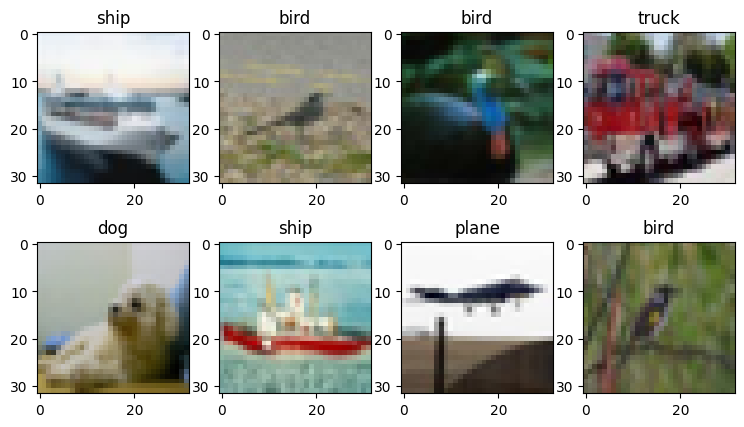

In [22]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(device)

# The batch size
batch_size = 2048

transform_train = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])
transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])

train_set = torchvision.datasets.CIFAR10(
    root="./data", train=True, download=True,
    transform=transform_train,
)
test_set = torchvision.datasets.CIFAR10(
    root="./data", train=False, download=True,
    transform=transform_test
)

train_loader = DataLoader(
    train_set, batch_size=batch_size, shuffle=True,
    num_workers=2
)
test_loader = DataLoader(
    test_set, batch_size=batch_size, shuffle=True,
    num_workers=2
)

classes = (
    'plane', 'car', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
)

n_img = 8

f, ax = plt.subplots(2, 4, figsize=(9,5))
dataiter = iter(test_loader)
images, labels = next(dataiter)

for i in range(n_img):
    npimg = images[i]/2 + 0.5
    npimg = npimg.numpy()
    ax[i%2,i//2].imshow(np.transpose(npimg, (1, 2, 0)))
    ax[i%2,i//2].set_title(classes[labels[i]])



In [23]:
class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 6, 5)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(6, 16, 5)
        self.fc1 = nn.LazyLinear(120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = torch.flatten(x, 1) # flatten all dimensions except batch
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x


cnn = CNN().to(device)

criterion = nn.CrossEntropyLoss()
optimizer_cnn = torch.optim.Adam(cnn.parameters(), lr=0.001)


for epoch in range(1):  # loop over the dataset multiple times
    running_loss = 0.0
    aux = 0
    for data in train_loader:
        if aux == 0 and epoch == 0:
            print('this is how to load a training batch')
        aux += 1


this is how to load a training batch


Primeiramente, iremos definir algumas funções auxiliares essenciais para o treinamento e a avaliação do modelo; em seguida, procederemos com um treinamento simples da CNN, sem a aplicação de ajustes dinâmicos na taxa de aprendizado ou qualquer critério de parada antecipada.

In [37]:
def train_one_epoch(model, dataloader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, labels in dataloader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)

        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc


def evaluate(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * inputs.size(0)

            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

num_epochs = 10

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

for epoch in range(num_epochs):
    train_loss, train_acc = train_one_epoch(cnn, train_loader, optimizer_cnn, criterion, device)
    val_loss, val_acc = evaluate(cnn, validation_loader, criterion, device)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    print(f"Época {epoch+1}/{num_epochs}:")
    print(f"  Treino   - Loss: {train_loss:.4f} | Acc: {train_acc:.4f}")
    print(f"  Validação - Loss: {val_loss:.4f} | Acc: {val_acc:.4f}")

Época 1/10:
  Treino   - Loss: 2.2571 | Acc: 0.1900
  Validação - Loss: 2.3078 | Acc: 0.0850
Época 2/10:
  Treino   - Loss: 2.2571 | Acc: 0.1900
  Validação - Loss: 2.3078 | Acc: 0.0850
Época 3/10:
  Treino   - Loss: 2.2571 | Acc: 0.1900
  Validação - Loss: 2.3078 | Acc: 0.0850
Época 4/10:
  Treino   - Loss: 2.2571 | Acc: 0.1900
  Validação - Loss: 2.3078 | Acc: 0.0850
Época 5/10:
  Treino   - Loss: 2.2571 | Acc: 0.1900
  Validação - Loss: 2.3078 | Acc: 0.0850
Época 6/10:
  Treino   - Loss: 2.2571 | Acc: 0.1900
  Validação - Loss: 2.3078 | Acc: 0.0850
Época 7/10:
  Treino   - Loss: 2.2571 | Acc: 0.1900
  Validação - Loss: 2.3078 | Acc: 0.0850
Época 8/10:
  Treino   - Loss: 2.2571 | Acc: 0.1900
  Validação - Loss: 2.3078 | Acc: 0.0850
Época 9/10:
  Treino   - Loss: 2.2571 | Acc: 0.1900
  Validação - Loss: 2.3078 | Acc: 0.0850
Época 10/10:
  Treino   - Loss: 2.2571 | Acc: 0.1900
  Validação - Loss: 2.3078 | Acc: 0.0850


In [40]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
from torch.optim.lr_scheduler import ReduceLROnPlateau
import copy

# Dispositivo
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Transformações: converte para RGB (3 canais) + tensor
transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),  # converte imagens de 1 canal para 3 canais
    transforms.ToTensor()
])

# Carrega o dataset (ex: MNIST)
train_dataset = torchvision.datasets.MNIST(root='./data', train=True,
                                           download=True, transform=transform)
validation_dataset = torchvision.datasets.MNIST(root='./data', train=False,
                                                download=True, transform=transform)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)
validation_loader = torch.utils.data.DataLoader(validation_dataset, batch_size=64, shuffle=False)

# Modelo CNN esperando imagens com 3 canais
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=6, kernel_size=5)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(6, 16, 5)
        self.fc1 = nn.Linear(16 * 4 * 4, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)  # 10 classes no MNIST

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))  # [batch, 6, 12, 12]
        x = self.pool(F.relu(self.conv2(x)))  # [batch, 16, 4, 4]
        x = x.view(-1, 16 * 4 * 4)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

# Inicializa o modelo
cnn = CNN().to(device)

# Otimizador e critério
optimizer = torch.optim.Adam(cnn.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

# Scheduler para reduzir a LR se val_loss não melhorar
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5,
                              patience=2, min_lr=1e-5, verbose=True)

# Early stopping
patience_early = 3
best_val_loss = float('inf')
epochs_no_improve = 0
best_model_wts = copy.deepcopy(cnn.state_dict())

# Loop de treino
n_epochs = 30
train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []

for epoch in range(n_epochs):
    cnn.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = cnn(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total += labels.size(0)

    train_loss = running_loss / total
    train_acc = correct / total
    train_losses.append(train_loss)
    train_accuracies.append(train_acc)

    # Validação
    cnn.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        for inputs, labels in validation_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = cnn(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            val_correct += predicted.eq(labels).sum().item()
            val_total += labels.size(0)

    val_loss /= val_total
    val_acc = val_correct / val_total
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    print(f"Época {epoch+1}/{n_epochs}:")
    print(f"  Treino     - Loss: {train_loss:.4f} | Acc: {train_acc:.4f}")
    print(f"  Validação  - Loss: {val_loss:.4f} | Acc: {val_acc:.4f}")

    # Ajusta LR se necessário
    scheduler.step(val_loss)

    # Verifica melhora para early stopping
    if val_loss < best_val_loss - 1e-4:
        best_val_loss = val_loss
        epochs_no_improve = 0
        best_model_wts = copy.deepcopy(cnn.state_dict())
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience_early:
            print(f"Early stopping na época {epoch+1}")
            break

# Carrega o melhor modelo
cnn.load_state_dict(best_model_wts)



100%|██████████| 9.91M/9.91M [00:00<00:00, 54.5MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.61MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 14.0MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 4.18MB/s]


Época 1/30:
  Treino     - Loss: 0.2505 | Acc: 0.9235
  Validação  - Loss: 0.0720 | Acc: 0.9774
Época 2/30:
  Treino     - Loss: 0.0765 | Acc: 0.9761
  Validação  - Loss: 0.0606 | Acc: 0.9794
Época 3/30:
  Treino     - Loss: 0.0549 | Acc: 0.9829
  Validação  - Loss: 0.0408 | Acc: 0.9872
Época 4/30:
  Treino     - Loss: 0.0422 | Acc: 0.9862
  Validação  - Loss: 0.0452 | Acc: 0.9855
Época 5/30:
  Treino     - Loss: 0.0349 | Acc: 0.9891
  Validação  - Loss: 0.0538 | Acc: 0.9841
Época 6/30:
  Treino     - Loss: 0.0302 | Acc: 0.9904
  Validação  - Loss: 0.0320 | Acc: 0.9908
Época 7/30:
  Treino     - Loss: 0.0246 | Acc: 0.9923
  Validação  - Loss: 0.0352 | Acc: 0.9892
Época 8/30:
  Treino     - Loss: 0.0236 | Acc: 0.9924
  Validação  - Loss: 0.0319 | Acc: 0.9896
Época 9/30:
  Treino     - Loss: 0.0181 | Acc: 0.9943
  Validação  - Loss: 0.0339 | Acc: 0.9901
Early stopping na época 9


<All keys matched successfully>

Note que o critério early stopping foi acionado pois a val_loss não apresentou melhoras até a última época.
Agora que escolhemos o modelo ótimo (best_model_wts), podemos visualizar os feature maps da CNN treinada para entender o que a rede está aprendendo em cada camada. Essa análise ajuda a interpretar como as camadas convolucionais transformam a imagem original, extraindo gradualmente padrões de baixa até alta complexidade.


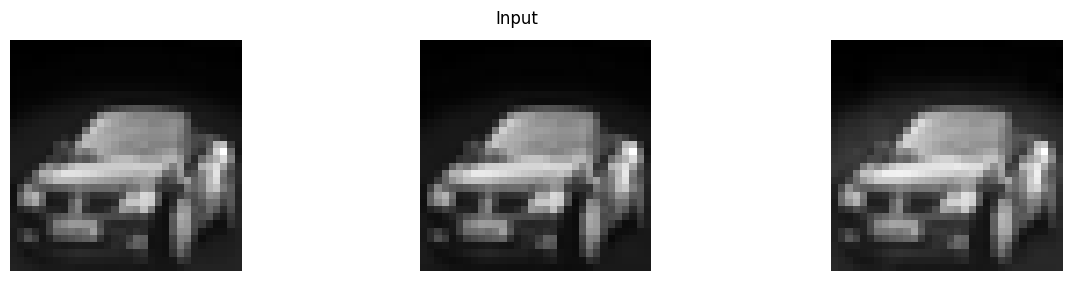

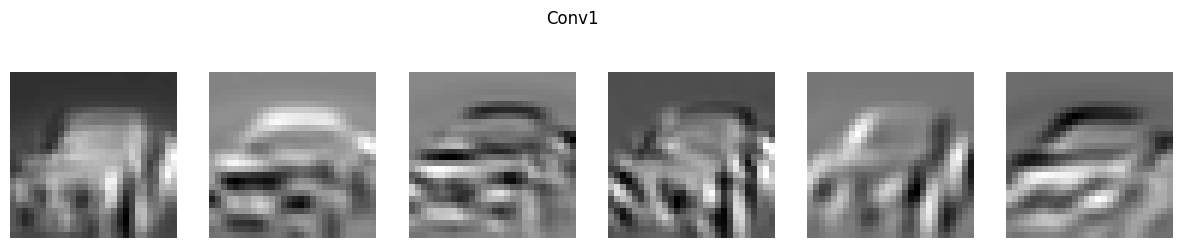

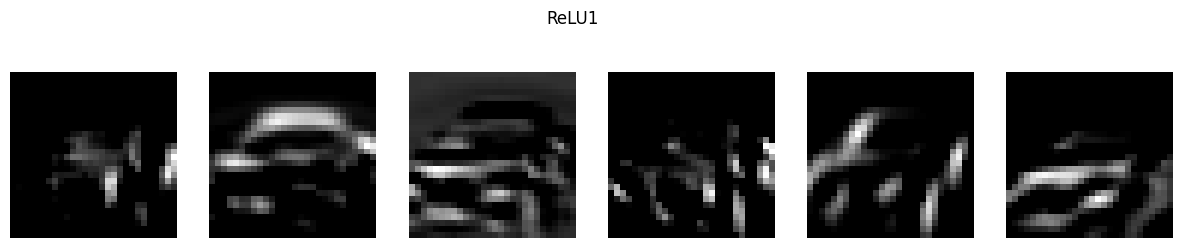

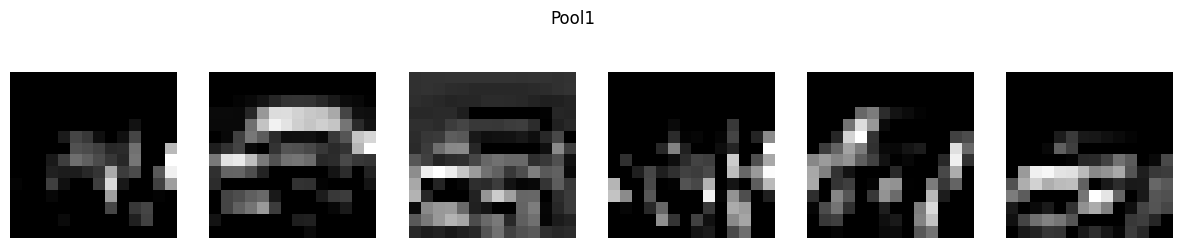

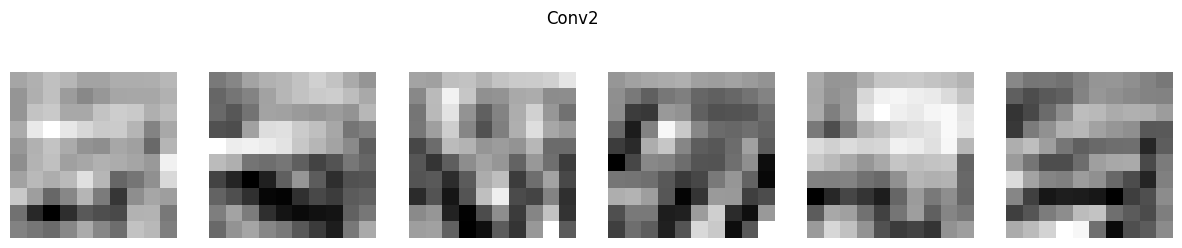

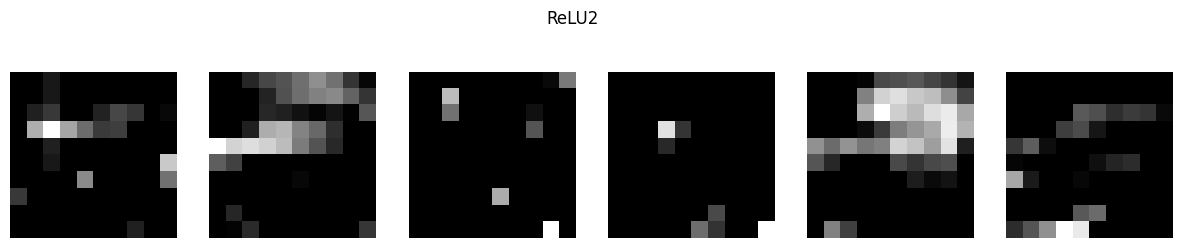

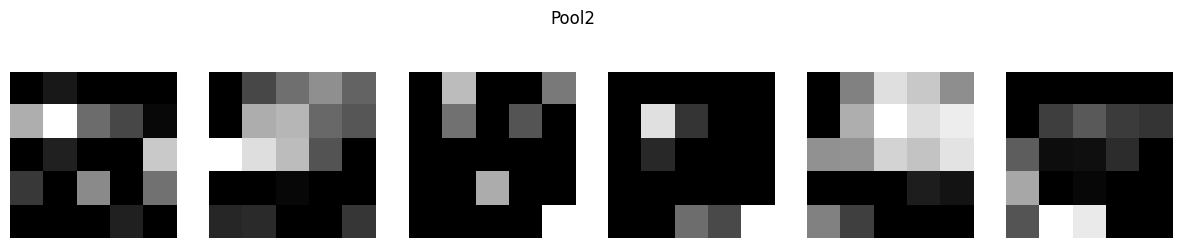

In [41]:
# Função para visualizar os feature maps
def plot_feature_maps(model, images, layer_names=None):
    model.eval()
    with torch.no_grad():
        x = images.to(device)

        # Passo 1: primeira convolução + ReLU + MaxPool
        conv1 = model.conv1(x)
        relu1 = F.relu(conv1)
        pool1 = model.pool(relu1)

        # Passo 2: segunda convolução + ReLU + MaxPool
        conv2 = model.conv2(pool1)
        relu2 = F.relu(conv2)
        pool2 = model.pool(relu2)

        layers = [x, conv1, relu1, pool1, conv2, relu2, pool2]
        layer_names = layer_names or ['Input', 'Conv1', 'ReLU1', 'Pool1', 'Conv2', 'ReLU2', 'Pool2']

        for i, (layer_output, name) in enumerate(zip(layers, layer_names)):
            # Seleciona só a primeira imagem do batch e os primeiros 6 canais
            img = layer_output[0].cpu()
            num_channels = min(6, img.shape[0])

            fig, axs = plt.subplots(1, num_channels, figsize=(15, 3))
            fig.suptitle(name)
            for j in range(num_channels):
                axs[j].imshow(img[j], cmap='gray')
                axs[j].axis('off')
            plt.show()

# Pegue um batch do test_loader
dataiter = iter(test_loader)
images, labels = next(dataiter)

# Rode a função usando seu modelo treinado e algumas imagens
plot_feature_maps(cnn, images[:1])


Em suma, a análise dos feature maps de uma Convolutional Neural Network (CNN) oferece insights cruciais sobre seu funcionamento interno. Observamos que as camadas iniciais da rede são responsáveis por identificar características de baixo nível, como bordas, texturas e cantos. Esses padrões locais, essenciais para a percepção visual, são extraídos e representados nos feature maps dessas primeiras camadas. À medida que a informação progride pelas camadas mais profundas da CNN, notamos uma transição fascinante. As camadas subsequentes aprendem a combinar e compor essas características elementares em representações mais abstratas e complexas. Essa hierarquia de abstração é uma das propriedades mais poderosas e distintivas das redes convolucionais bem treinadas, permitindo-lhes capturar relações intrincadas nos dados e desenvolver uma compreensão rica do conteúdo visual.

Finalmente, após o processo de treinamento e otimização, a etapa indispensável é a avaliação do modelo com os pesos otimizados no conjunto de teste. Esta avaliação final é de suma importância, pois fornece uma estimativa imparcial e realista do desempenho do modelo em dados que ele nunca viu durante o treinamento. É nesse momento que se verifica a capacidade de generalização do modelo, ou seja, sua aptidão para aplicar o conhecimento aprendido a novas situações. Um desempenho robusto no conjunto de teste é um indicativo forte de que o modelo está apto a ser implementado em cenários do mundo real, garantindo sua confiabilidade e eficácia em tarefas práticas.

# Gaussian Processes

In [46]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
import torch
import torch.nn.functional as F
from torch.autograd.functional import hessian
from torch.distributions.multivariate_normal import MultivariateNormal
import seaborn as sns
import io
import base64

**1.** Durante a aula, discutimos como construir uma priori GP e o formato da posteriori preditiva para problemas de regressão com verossimilhança Gaussiana (com média definida pelo GP). O código abaixo cria um GP com kernel exponencial quadrático, mostra a priori preditiva e a posteriori preditiva. Experimente com o código e comente a influência de ambos os parâmetros do kernel exponencial quadrático, tanto na priori preditiva quanto na posteriori preditiva. Nos gráficos gerados, os pontos vermelhos são observações, as curvas sólidas azuis são a médias das preditivas e o sombreado denota +- um desvio padrão.

Text(0.5, 1.0, 'GP posterior')

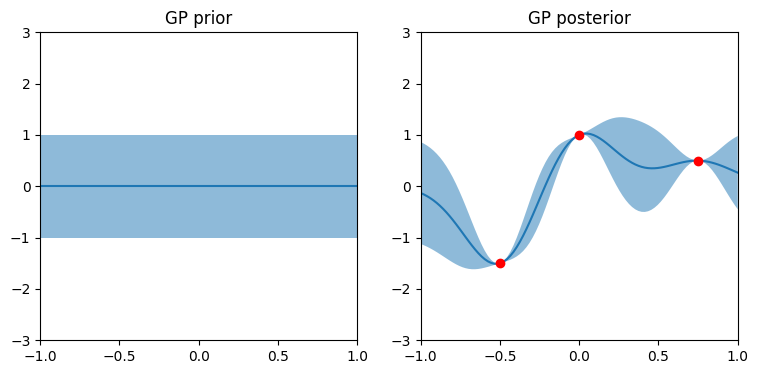

In [47]:
SEED = 42
np.random.seed(SEED)

s2 = 1e-04 # variância observacional

def rbf_kernel(x1, x2, gamma=10.0, c=1.0):
    assert(gamma>0)
    assert(c>0)
    return (-gamma*(torch.cdist(x1, x2)**2)).exp()*c

x = torch.linspace(-1, 1, 100)[:, None]

K = rbf_kernel(x, x) + torch.eye(x.shape[0])*s2
mu = torch.zeros_like(x)

fig, axs = plt.subplots(1, 2, figsize=(9, 4))

axs[0].plot(x, mu)
axs[0].fill_between(x.flatten(), mu.flatten()-K.diag(), mu.flatten()+K.diag(), alpha=0.5)
axs[0].set_xlim([-1, 1])
axs[0].set_ylim([-3, 3])
axs[0].set_title('GP prior')


xtrain = torch.tensor([-0.5, 0.0, 0.75])[:, None]
ytrain = torch.tensor([-1.5, 1.0, 0.5])[:, None]

def posterior_pred(x, xt, yt, gamma=10.0, c=1.0):
    Kxxt = rbf_kernel(x, xt, gamma, c)
    Kxt = rbf_kernel(xt, xt, gamma, c) + torch.eye(xt.shape[0])*s2
    Kinv = torch.linalg.inv(Kxt)
    Kxx = rbf_kernel(x, x, gamma, c)

    mu = Kxxt @ Kinv @ yt
    cov = Kxx - Kxxt @ Kinv @ Kxxt.T
    return mu, cov

post_mu, post_cov = posterior_pred(x, xtrain, ytrain)
axs[1].plot(x, post_mu)
axs[1].fill_between(x.flatten(), post_mu.flatten()-post_cov.diag(), post_mu.flatten()+post_cov.diag(), alpha=0.5)
axs[1].scatter(xtrain, ytrain, color='red', zorder=5)

axs[1].set_xlim([-1, 1])
axs[1].set_ylim([-3, 3])
axs[1].set_title('GP posterior')


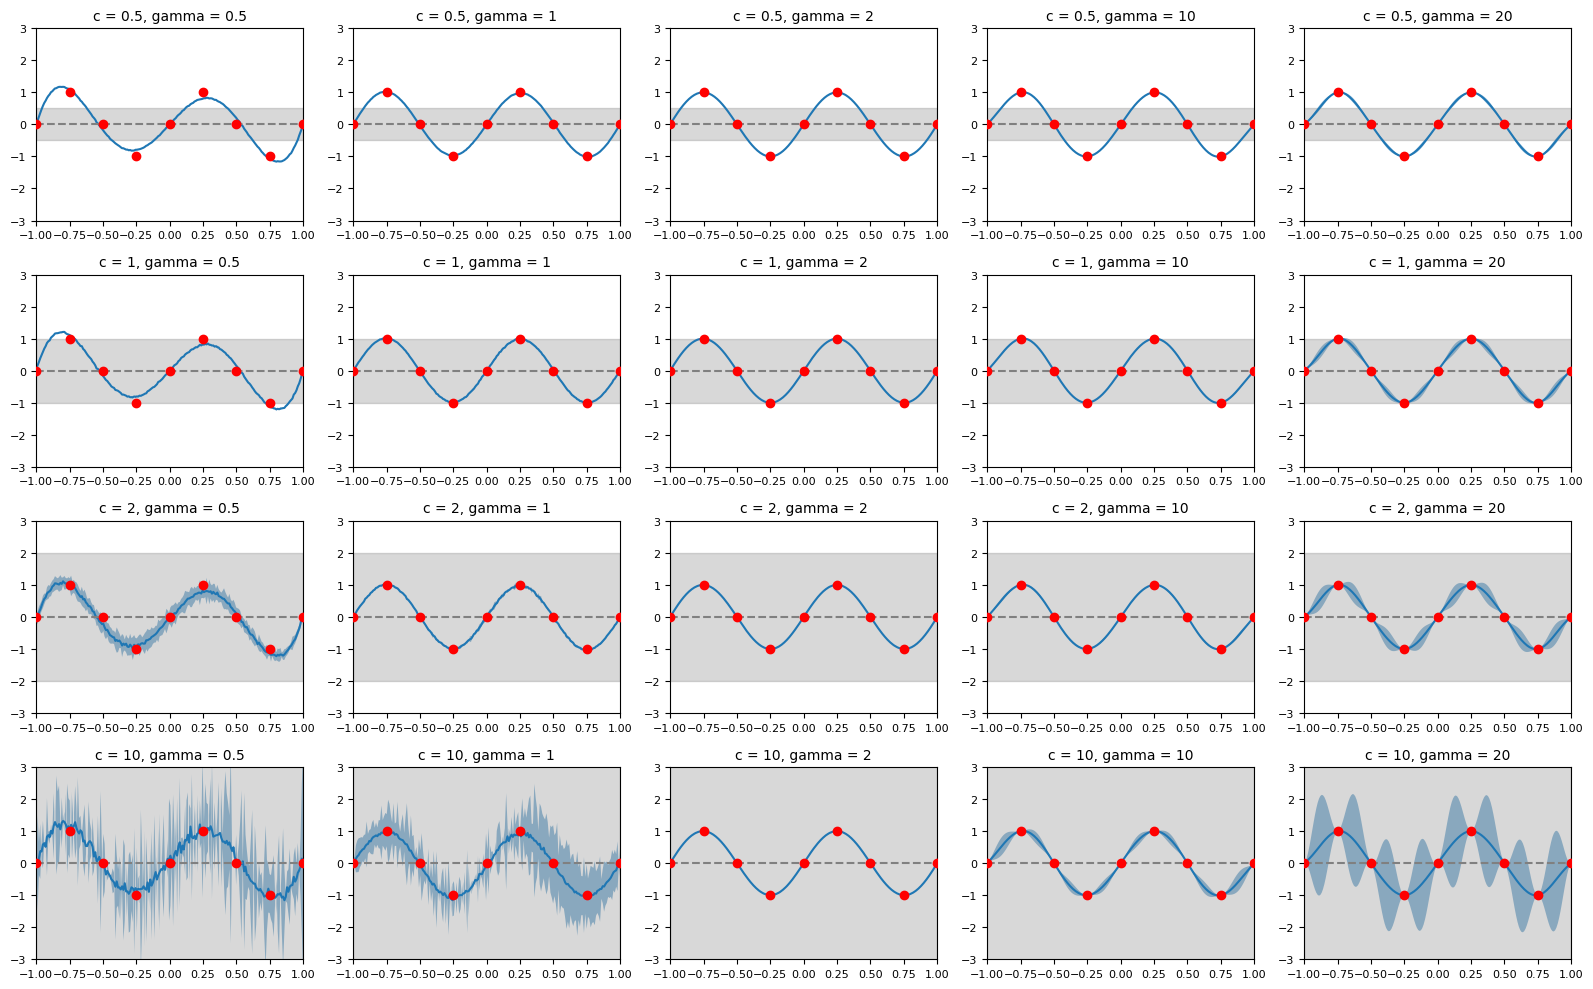

In [50]:
import numpy as np
import matplotlib.pyplot as plt
import torch

# === DADOS DE EXEMPLO (substitua pelos seus) ===
# x_treino, y_treino devem ser arrays 1D
x_treino = np.linspace(-1, 1, 9)
y_treino = np.sin(2 * np.pi * x_treino)

x = np.linspace(-1, 1, 200)

# === CONVERSÃO E FORMATAÇÃO ===
def to_tensor_column(v):
    if isinstance(v, np.ndarray):
        v = torch.tensor(v, dtype=torch.float32)
    if v.dim() == 1:
        v = v.unsqueeze(1)
    return v

x = to_tensor_column(x)
x_treino = to_tensor_column(x_treino)
y_treino = to_tensor_column(y_treino)

# === DEFINIÇÕES DE KERNEL E PREDIÇÃO ===
def rbf_kernel(x1, x2, gamma, c):
    dists = torch.cdist(x1, x2, p=2) ** 2
    return c * torch.exp(-gamma * dists)

def posterior_pred(x, x_train, y_train, gamma, c, s2=1e-6):
    K = rbf_kernel(x_train, x_train, gamma, c) + s2 * torch.eye(x_train.shape[0])
    K_s = rbf_kernel(x, x_train, gamma, c)
    K_ss = rbf_kernel(x, x, gamma, c) + s2 * torch.eye(x.shape[0])

    K_inv = torch.linalg.inv(K)
    mu = K_s @ K_inv @ y_train
    cov = K_ss - K_s @ K_inv @ K_s.T
    return mu, cov

# === VISUALIZAÇÃO ===
cValues = [0.5, 1, 2, 10]
gammaValues = [0.5, 1, 2, 10, 20]
s2 = 1e-6  # variância do ruído

fig, axs = plt.subplots(len(cValues), len(gammaValues), figsize=(16, 10))

for i, c in enumerate(cValues):
    for j, gamma in enumerate(gammaValues):
        # PREDIÇÃO POSTERIOR
        post_mu, post_cov = posterior_pred(x, x_treino, y_treino, gamma, c, s2)
        axs[i, j].plot(x.numpy(), post_mu.numpy(), label='Posterior mean')
        axs[i, j].fill_between(
            x.flatten().numpy(),
            (post_mu - post_cov.diag().unsqueeze(1)).flatten().numpy(),
            (post_mu + post_cov.diag().unsqueeze(1)).flatten().numpy(),
            alpha=0.5, label='Posterior var'
        )
        axs[i, j].scatter(x_treino.numpy(), y_treino.numpy(), color='red', zorder=5)

        # PRIORIZAÇÃO (opcional para comparação)
        K_prior = rbf_kernel(x, x, gamma, c) + s2 * torch.eye(x.shape[0])
        mu_prior = torch.zeros_like(x)
        axs[i, j].plot(x.numpy(), mu_prior.numpy(), linestyle='--', color='gray', label='Prior mean')
        axs[i, j].fill_between(
            x.flatten().numpy(),
            (mu_prior - K_prior.diag().unsqueeze(1)).flatten().numpy(),
            (mu_prior + K_prior.diag().unsqueeze(1)).flatten().numpy(),
            alpha=0.3, color='gray', label='Prior var'
        )

        axs[i, j].set_xlim([-1, 1])
        axs[i, j].set_ylim([-3, 3])
        axs[i, j].set_title(f'c = {c}, gamma = {gamma}', fontsize=10)
        axs[i, j].tick_params(labelsize=8)

plt.tight_layout()
plt.show()


Com base na implementação realizada no código, podemos reescrever a análise da influência dos hiperparâmetros
𝛾
γ e
𝑐
c da seguinte forma:

1) A faixa cinza tracejada (priori) muda conforme alteramos
𝛾
γ, mesmo com
𝑐
c fixo.
Isso indica que, nesta implementação,
𝛾
γ influencia tanto a priori quanto a posteriori. Isso ocorre porque o kernel RBF é usado diretamente na construção da matriz de covariância da priori, e o parâmetro
𝛾
γ controla o decaimento das similaridades — quanto maior
𝛾
γ, mais local é a influência de cada ponto. Assim, vemos faixas cinza mais estreitas e irregulares com
𝛾
γ alto, e mais suaves com
𝛾
γ baixo.

2) A linha azul (média da posteriori) fica menos suave e a faixa azul (desvio padrão da posteriori) tende a aumentar com valores maiores de
𝛾
γ.
Isso mostra que
𝛾
γ está associado à capacidade do modelo de se ajustar aos dados: com
𝛾
γ alto, a função resultante se torna mais sensível a pequenas variações nos dados (menos suave), enquanto com
𝛾
γ baixo, a interpolação é mais suave, refletindo uma suposição de maior correlação entre pontos distantes.

3) O parâmetro
𝑐
c controla a escala da variância do kernel e, portanto, afeta tanto a faixa cinza (priori) quanto a faixa azul (posteriori).
Com
𝑐
c maior, as faixas de incerteza (cinza e azul) se alargam, refletindo maior variância do modelo. Além disso, o efeito de
𝑐
c é mais pronunciado quando
𝛾
γ também é alto — nesse cenário, o modelo se torna mais confiante localmente, mas com grande variabilidade geral. Quando
𝛾
γ é baixo, o efeito de
𝑐
c ainda está presente, mas o aumento da faixa azul é mais gradual.

**2.** Durante a aula, discutimos como escolher os hiper-parametros do nosso GP. Estime os parâmetros ótimos para os dados carregados abaixo (acredite, é isso que o código faz). Reporte a evidência obtida e faça um plot similar ao acima. Para o dado de teste, reporte a i) log verossimilhança e ii) o MSE com relação à média. Em caso de dúvidas, recorra a nota de aula e o link adicionado no eclass.

In [51]:
data = np.load(io.BytesIO(base64.b85decode(
    'P)h>@6aWAK2mk;8Apo$)IktlX005u^000XB6aaK`VQFq(ST1gGc>w?r0H6Z^000000D}Vn000000G-JFQ_}?;!0~YzY=9g==Y&XhJ79<?P+Lz&d|0HoP>&SM'
    '2NI?X(A<!XAf&F9gxYZsB1plJNq0ihIRZpQ_$**23=qcCzMEScGRBv|9&{@)AhLg<_iyi4)xOld$%ox21(ae|ra*E+%zB5xip_e970F;_<%;vgd{KI?I8*SS'
    '@8X}92%ftnhkr)!{KI3SqaztHTO%1?F#czrlL<L1=1>jXSP9_`ra#1EFBN&dUp#}93U`}z=Uq7W<3m;jT?g?mc%DzX*@x|yc(1GbZBQcI^|rK04V2BBL^Y+2'
    '2>OV&sD>fT|N5`c9=}Oc-;Ux)Kh#5%KK0C}5=2f&UT^G<B|Itrr%Vx`M7!#hh-(FZfcVH+w$FYOzHvTfU7#>wvZ_WXWywJL>hZevBpDQT^trs*DhO5Dx6wZ~'
    '!v-$V<-Dtd`E%k=Xs3rE#nf`py+{YH_eyu}Zl1;=a)XkTsql7Za04@Q26fwFD3`OfxLm?bo9G(@bL+s2Gth#yia`8xS&mna<{tU`x8IS%3~Ifuzle^nF1$Oq'
    '+KbUaeQpyT1dh$Edi<>I#kEak-MsA!kV)ShvPHNAZV}_Rs^}u9td17*yGFs8ad~gY_ar)B^!hCNgc^wsrl)g6fk9cRPwVpLp>u+}<>ki)l;5d}FHHXl{WZG7'
    'C;jap_g;LHbT)#a(VMt#9tJ9t)!vXuq6qn={f|sQnfIcF9an-Xxcex}zY}Csq9U0wi6sGLmP$Vj62*^s)Hnt9+sTc3wi*r;gfKt%AR%64&EI#Z8d7FHaQU@N'
    'frB|1=vY_4L7yh-ug^wd53_iglQs<lTeG<iat;hn&RT6P7JRVASl@0mg7!vvm?GPVu0}7Nrg9cDLWkVHE$fAnxT!kAuz*F65;ZZ+B$)Esds=y8P*zU@S*wFK'
    'w<vb^QyY$cXQ9a=2f&wBV0_}&4N|+@`oqK=);7=Hp|j1XuDMqk<e`D^gt6@A*VOpYsq*sTO9Z4Fo^1>!x}a9VXWtVJ<Lb(^`50#rcGzT7i~2cO`tsJoQ2aQa'
    'N(u`b=2&rY#1fFUM&Q*1;RC6!5@Yw1yXmo7=qaT7y4vhOHYq#!dE*%FTX3j)#0ZX}3~rwGKGbt4aW^j#Fnz!28|wixCgxm8jGG<AU+R5ARn<n6GToWiXp{Ia'
    'P)h>@6aWAK2mk;8Apk!*Q7DH4005u^000XB6aaK`VQFq(c`j~nc>w?r0H6Z^000000EYtr000000G*KSGaCjRfKy`8t*7DEnx=P)x;5ltqPkwS_{k~h(iOYe'
    'O?L<t%BCWTWlE8&iF)a%+|5NB+ODeRWn$XRgdeh1hY^vq1VIv~=?xX@wI;3Ezp&@q^L%_{k)NK9KC^=$Cgjn0DWYT{?HH97lzNoLpwd$L!fatuCYLYdrTo_;'
    'k}^ao+g+5Fl$EmW-u_G`gX-_YpypHmCvWQRlTzoBC(vOzFCY7KAgjDN%<$4duk3PdbIm0DDZgC&UhWh|#(pJ`*DgZi?~DzubqGv7CqC?ppGEf5&gcODRk&;S'
    '&hcASfrB($S$FR@kY=?lb<(Gib8=If@uL-N#|GT}&W>R30q<aG>0{`8IsfaOu5M&p-|t>h-hh_+8izM_D3Rsc_<o7_Dct(U@d$C!3=QvkbQpRTP*GjTUhg)d'
    'GN9TR5<P>VBG&+cUW?hxvb3mHBNCk}<wU1Z@Y)r6?}N5sP(6F>sn|OTt97sDDBr1pNp>0ITsLF<iDvt`*d9pJz8yH&Z-mG%-MjouW=M>Rjk#a<3?38&>eoZf'
    '&{rmIjyOC4H&!gSPBEW=x>BadcI?4#oQHRb_!=0WmIPe2tpQ>3cHzDwb9l<-w4-mrAX?+aI~%#(5O<|y;$+(+NTkSFyD#eS!kM~1#t3?7sN%mRuD3y4aCoux'
    '!8q88>=k7BUl9H67Y=0-4aWMYifd-Cg70`CAwAcC50l9;1I`9a=(4diTV{w;hBh51Yhc3eIlD)qg{lq<otU}+L0rw}WgcdXu?pzZ6g3h{1LFk-8&uF~KWK9;'
    '7+##?dMTqFcmHBoT$auw@4{zb;h1oxmb@O}G>841YXz;dW9Y_OQJi}*gX%it0Qt5SoL+x2*<|m4wUDAs*C#(img;=r7PSeYu7o*DLe$uj_xy&}-~uj@vWxVj'
    'X)G^x&s^R}MAP?#!2`AZxUc-+T$SAjlDi8(c{&awpWPX@*G&f1A*5@R7iNq&xUpH?G6Y-eKBS821<Y?%vKP0%S$B%3Y-__1e4JF@a<~REU%Dt*?Rwnb;9a@&'
    'wHnxLtM(DOAO6lwpHeclu;-FFotH2Ql$kZZv%GoC2`jxrXx2bq`#a}@p7#Qm^6{vaGlWM4>+XkiP57GV!8t@XVOEeqSdj7%=i4Q2d8tkCk*RUy)yNQByr~*V'
    'RM*14P)h>@6aWAK2mk;8Apn6>1aKG%001Bm000UA6aaK(b97%=E^csn0RRvHAP@im000007zzLY00000omcx~j%6R8w`g=49gOr^hM}ny%_{j!$)TvxfsiKK'
    'sKiWZBW<J_t;k_fVx=^dEEYD)XUy5mFx$-O+4<SCqeGF%dtdkG{tMpchwVAs_jO;__xt^vmOS^;u&`H}dCl;e6%Y|QeL_sYV}1dBqe21#{Q{z<#=H|Ve#&c8'
    'V<IBW_XEdIo*rp^KYh~p=t%2xw?~440{tH99_TmQ@Be(Y^0Hq|EV*^>(jI3UnSRgb-Cx??$c5J5_-`6Hu}_B=etN%={huzcE*R5D^Xd9yjr=QoTI(L|8<{sH'
    'WbKQ8H*lTxZG3S9KU}cq@VYGxe0BL}5e3N&G{64)ZUgVI7j9tvj<QZK_HN)_>#7g#XyBUD(L>jrujkC#KBdQw)YDx3Z(2QrZranT`=WZbyz8^oFHEgxsdd)}'
    '&($+4=$`$lJ?oj=uk6)hx75?zeXX{R&yJ4%q}#zdc9~>0Tt~CY?D=&p`Ed8ssgvrs@r$IAql4;bR=d`<juY3nzp-13I`-dIx_m@sE!$hG&fZnai-l8n{<x-='
    'hbw|d9-UiDv-;KXwVda*J0YNdEyvxKbk_*KT87w#@UTsf_W1FPhxKOre|Tt~c6FtPDdsWndpL7^@Z#ZPJbcl7e9S}ZA=}or^YErmKMgx_xrXNH{}k0QYi+xk'
    'UANRQIo);J@Z=gsTf3O`ZViXzn*!Ic%b7<G<@c(g+08#~YFPYt&R<>5ySdR`$W61WS!r%Y`nUW2hlOt9A(wTln`U=chPioh=#=SQdb*i6`VsH2Tije{?Q&*q'
    'HRsI8dFY1&)f_v|G_IOvw^tIY>67By)Ok`hJ?qcTdwx(gcW*NrtmdlyZ~yvz^J>Nx^?vGbMHOGLcK>%y6?<OTIl1$iD&Ev=L9^%QR<YDNMcnu*ZtLKC|M#I)'
    'w1$g$9jiFi9*9Z~8TfXM|Cvhqo3{Q@$!pfB;#O9&$drFpC4ZYezi-~?N+y{yJzB}A6>X#Z+f_2u9OrTc%_(DxDtOU6c5?;u@_S_*T2?{(=XWYNx6TY&1;<`V'
    'd~aB<3I<!Jj%`yxpS#<B``x*6di+g6%V|!3X+t?zVe)I87M3%1STCzo<s31_+*r=QH+J0nU0^v|yqCB!_vUiCtZH2HlreMh-KXw5P{ySxW`N5$#j47CiDev|'
    '_10J4PAp@m0}nr#JFtvbi%g@+SXh}o>b~Y>OuO(&{j(LNG*z0BQ_6_j&4x<Z@7~itADmN4Q?0+kOL;!zt>b>7rOX}p@SD$eETs*je_c#?J$p&YX&3Er&vMaJ'
    '@6WGYw8wImi#01wRXsD>#T+v}kGlBH?{8YIbg|*%3C}ERJj*rTottj;lrLN8#^keXCE(Lqq^ZVzhB2+}fo7MUTc27Qd4?r}?MCr)3(ft?PP4x@K>PA>r}>kG'
    'Vr%cT!1%<Hlc(6G@vA8Jic>V`ePYxp#&zA2VU>zOPZ|O_$#PxD<#7fWCpmOk<7?HopJX$;;U!GZy?K)bRZeo7gOu<d3#ENqmN38L<_EvndxG;GAMi@mM<*C!'
    'q4V(pCs-E~{>!5OoZ#xu8;)0I7t^Mv_+on78z|;B0gTZGewjt=tiho@zQILIGUN4UAwy03Hx=@tY0tDmrke5v6>=<Fnx*M;^2>eYzZ~Z-3w2g&IJ1o*wBzjg'
    'fPFBQ*+4B|a^yI}e0*k(8NdQwTWK>JH*WQ|nCuv%3T)<LdkbBCIviu3ecYp*8(^5|D1)D}nTMWnuUaiV%2gspjz~5IJHi$MJTnh1vzX!tr_|Vk%udbC5BV(g'
    '3pL2+g1!dn`FuakJoqpTd$Z+X4()jE*Ec@SWBSXt{^!mc^4QVPef%LN+QgO1Mnf-gxg2Q^)<I^QagI62ZfiDQY~6T(Usx=f_0|DiZfzR9pW#DpZt#iR&;1GJ'
    '0Q(qZ#%A0;F1OpdmtFx@*+=f>M7u0|m~XZ{d=Eno8Nlx5>Kp5=$=pqEtI4<S-NoqXX7YBi_$M=IISe&4|3nT`4LxS;q>rJM;GK*$aNM+mE{jz*Ke&T~FL|s<'
    '$Y%NjMmVw=VgrZtemuT-`+)5%GIG=J52hMg>yyP;1D~L69ApbwCfi0Dg2|xUV)4ulTe;=QRu(k3F!49@W-~`x?7G$acXnU6$*NpBFWE%Ak^2n&T>Op8PmZ-J'
    'k;Z(R=r%Aq=Ii_4*s-2IhIZ0_<_4Si*D=hLYsHUjbejhMz(qzbKUl*c1N&*;GUbK|AKkfc70+%T@ZX8+zhbC4_Tps58`_Rt%y=U+nMu4p@=NQ=dAz>T06do0'
    '?})SBh108z{U2WX9tpY*Ub+vVS_fWQ7uk9a67*d7X&*??zTnb65vqM-wa$TNIv2uqPGsxcSfn~2TXjK`>I6U44bQ8NNKjporaGfkb%&4ofKc@X(drXY)HfVf'
    'AJI&GMUeW84eC2WH3ultTp(I=0&mR?R%?zBqPar8<_wcGckt32V!7rLL7G$S)7&ClbBxPf?YYK6%{jVh?vX7VV3cryCgB8$!VUa{BV-6y2ouiW7Va=dIE1fo'
    'i8SF9Lxfwngk!`C*GLr3Q6Su-qj&&six;p}Jb@d;8weARK(urO)#4fS7VjWIJcNVdCHRV`5Fy?|ns^LXwEzZ-=de_~2bXvdf#OBPiYJjR-o!29QH&C=;(PHd'
    'n#8;4D;`Focp1mU)9@2-W3qT08RB&`7tbS1ypOM?18_?h&|5lzInoW}N=M);UBLwD4AP`KxSD3`5C%z?uv9t)mvjsFOUDo^UBfQv9B!BHVXSlzsnSJUkWM00'
    'x``y|D2k=4=q#PZH0ds~q{Hx*F5@NXG*YD7sFRLkrF0!TrSou0_u=>eIKBXmPk`ea;P?nQz5-418Ms@%1AXN~@Va~n=F6wxSNRqc$j9J{d=32Mb1+c82b1N4'
    'uvoqbTji5*M!pF*%15Dxd=<jvvoJ%x3oGTruv5MaZuvCaCf|nM@^Kg~Uxx(wJgk-PL#})v&dV3VS3VK_<QowoABhF>l}MA%M4@~quF8j^lYA-Erb<kaZ-wJy'
    'kttsbmwYZ-$oC>pJ{ZI0i{bcWIKCN<kA~x`;rMJgz8j7YhvUn!Rz4lM^6fY$ACI>3^>BPXBINrqUpWA2$^|&CoPd9n8{n@Tfx*fZn4+A4CCVMhP!54hxdcv5'
    'L7;LAhAYP)PPqo(DCc08at}PpLGV#7La=fY#wa&oj&c-Im8+1aoCPO$p`CIVpj-wgry)tX4Ni_jv2q=poCkm9J~%lLPA<eU<wQ8S5l)Uo3*|~YpqvROcOp(X'
    '6swg>;p9}*D!0PPu?SYKg_CnJSGgB!m4o5rVq8#8hOcrnoE(iP<!U4;XT!<eC{_-KlgsfxP)h>@6aWAK2mk;8ApnKqayn=a001Bm000UA6aaK(b97&ME^csn'
    '0RRvHAP@im00000Xb%7Y00000otODL6pYu#QzY9%;*q6HlD$%t@|06(AuY6^WF1>b3ME7#Yg!SNL|L+veK{CoUuK3emccN#EZJIA)Ytnjyyv&`xvq1a`#Se8'
    '_j!Ki;^}jy9BVw+c*_%QZ`s_G*CfavvO6HJLXfv}z3G0_>biyNO``4p@#9v`w`^DWEeER`wyV9uK2=o}!X8Bxf-m9!S-b}K>b6+MXW;Yee5~_^&tXkkhOa<|'
    '1!i+3Yw&nQBV`;e6~vf=L)=m<2Rj~9&#YkvoUntn23KZI#M80=gCl4pe!wf}DYn@@4sS$qq>|!N(JAL25j~DX3>bcRgQS@W5iVsJE6#c7ADL31>(>P9i#}UO'
    '31)(yfi%JTPY5n_r9Y>+B%r3iJCEY*7Z@8V&$w$+ieJAG_>vT(QEM_i_i9HZXzkiAwJ9eVv@3jH1|3a?HkpZ;ryU>gs@Jo!_42hS#xUdhoKS%KKU=>I;;#Y6'
    'YrzU4wz+WS^6Qrzv~bwA!9#Z2ND1~fTK-I4euY(EsRxt$Nf^i})^pak5U<dSRJf^Gn6~qF<01KcoRc{JNA7SsaB(qnG=}Su`#7JIz{zS1Q|(yz^Irq@D9NPF'
    'ey>B^^d~p;Rw_R3ZD-rYv>=7hS}^M910sHA;_vE;G5*F#XJSh(-tLoFE}*0$_2?7jR_iKUN<iNtg$T&;>-XlQmE)$@d&He%lhB2=?^@_a#0z2fFaG;B9}i4L'
    'tTCPbgmPc1P%ym^2|<5VBpsVEeXdqvqBS3b4&O=S`bNS7_MV@1N93UJ+sPSy!7h{tzw}@ylZrAy(-S>@C3xtZ_nv00RH(Ca|DmmtiBg@(@6>vlaQeq4-UACA'
    '$d{z^kj|Nhm7Moyhhj+hftAx3yR#6FXKa5|x1$<2$NM~7RINenD1-L}2T2elr`E1uSA)xAdfa(CYVnD8X%IS)a5`jb`KjdwoXF7?v_77Qt@ZZ)!@6YTUoXoU'
    'WtM|`#Vv~)w2F}+IPxif#2!Qgg=dq_<zYkMo!=F@tr&IRU@K{{6^Yi{8l9=h5ISGl>#~i6qGAU<OHMXpuIHDeLarKg&S_*wMrJ`etuWx&{YG5!xV~wtaWy)}'
    'KH`_tD?<Zwd#B+M5}xO5zbw#RjjeYc?aFVe#pP^6-pGGb(MQEr<3f5Ijz?*BSw^KIIUw}!{I+U*{p1iU<{TMn8uZ_U8GXWZX6(+0fFfWSSG*%hBp|>3KRX-V'
    'lc39hkdRJpfDO8GN8-6+z&WPz$imNDywEOD-Na}FOEvbl(~5MM^Rm7~lxqaGf};ufY(1#Ftv6bZpg?!*?%)T*6rfi5P#t3`U~8_8zL8E1h~maMzdkBh`KFqw'
    '8#TkdaHlhrNCy0YqoKz4>%jSsP2G1PIyjY2$ha)i;2zI~2u)uKD7PQbc@I6H;N~UM7SsiDp(z^<ST%s^Be!c;cp2b+KJV4UKTL2w{hn$}rh)nt(fGU`4JIY%'
    'e}yyK!N+WJ^A3$ps3hrh&d|GoU=^})JE;wR>2`>}Rd0a6L_ekJOEj?Ee6Wanx*iU5aa=AI>V^h3duzovDy-Ad2^FE#K<J`*Vw)BXDk9@fY!U4MjotCKdcV71'
    't}5=H=1&^TYG;nTe>4crk+vo0g(&dY)s&H%MuW&2+fZI%8Z-wc9hP`Xf!Y0}z}F)*$OuSCo#CcKhK*xQOI{C@2B+tf#!8`C%D!Z5Lle0BXGjT;H9}a5W=Em{'
    '9hmHO0k$%Y!0KI@E7+R|$)Wza+d5jHYhH26TCWM7OLL0kakfCfIdLK8N+F165BlUYy5MZ_{HO4O8ek?GA2ALf!6YM?%^{HwYzM)64`OoQtYAyPvQRvz*%{8i'
    '6fXk>?IJtr&}5kVdc5pq799rLYIX(iXJNy$U)%-1L%}JqN6EDP6I9$>*>^U#9yXnJ>rdd!hl9Q9cdKRVA!i8^m2)G2r`L1iQL#$+Xh8PArbB~T+L7kyoF_1^'
    'OsNT8B7u(1j&IV>szFp%H<y@Iij_Ldu?@vJP`7>ffZkXewAXDMtemTXlZ3hfi>VjjB`V;cOlbzDYyb1Tb7e4S(VOBxZ-j{Qn@!9M%|Jc4QSJDpd}vQ4rkPYy'
    ';lCpRiK)bLxYM7q)#P9?s9SOcD;tsEF(HIDD$)Y(@2{J2f2D$($6FP<#wNI?9NBwSsT<m3U86Nrx`6E{FGRdVg*Jowp&e;V$bDUHe*fbj7yx~KV4)l02<zrv'
    'NA$pVVj!`2g#wnFgX}JB?t|<*FXc_N`yqE%JbSm$5XcqpX|cM?0-{o4y-~<8)aaXZx!a6Gfv-zh-jgB7NH)%Lb{mGvI>V8!F)aAL*@W8XGYXX_M{Ke!KSNBK'
    'zO=FH5FC(fYDj%I3Ww8necKZ|0b$Y>E0v$8!2BDl%1~wsq&Mj74*W0$?>-(J+WmYIUSWh-fX@s>w^<16>6nG_&FRD>@;GGd{n@IsaSqgt7jBFQe*s^KpNbD)'
    '2DaK*tbE8A2gUPA2N@Alus1dP4RK-tisNMjx4i!XTF3Rb^^j*E#<riAe|28}QqqrOp|h~8!yL~zH4n``AzC6yi?HF@e)4adIas*2&+~4|JXAPlJ^rpY3+tl7'
    '!Y|A&f@?bU$TEE%m{Or<o!`zvyVUaC_Qlmb<du3ct3`OSXrxL`orgn|D!mo^8K_zmKP$-p6{e+FVO>w=!J?Q`Ql()5w974>(o1I{!H-&6PMw7hcZ}5>{O2IJ'
    '&6Z=LZyth$xzd9K=787R`C5+X6fCUmeIa5r3y--<@}32*>S`L+Ichlr4OTMU<IHIYGv|qVkvR^0n>uMf-Nqo(_r>=ILK7fb)nt{aJ^|N9+-?NtO+aA!O62Y3'
    'afo-%j$L^>1qtT+lgT&=GhW9Ag_g$Qd#n1x?3--J8PFhfDvpEljMCJ_%?t>XsQke%(hstO>3g@|U-diBgBb1I2g*4fkB1dl;FKX)>GQ4^M*N-qXutbl*wHvL'
    'E|CGH_TI$}jr3K0%p>OHZr~2oaR$Q<Fh6m0K~k0q7P4Y4W$x9$<L<*$fAj&?a10ZbU#r7)lVh4sZOdR^n`;KBwWDP<kJ9axT5Ryt%2C5wWC#Cq+M9^@Wa!~-'
    'FYX?ELACum{qi0DCvg1f(N|UI|M0!WjescBuhZ1}N2mtPMQzS)Unb+74a&LObMldv&a6Hj-i?38jE?H^uyBIw)y8}NJ!m$1t9ota0Pa2+2C@&Cxb!p3l+R-b'
    'nMZn$US##)gDWkAJuZEy(YIXYzlMdsLfV2QCI`^1H)l_U-4GhaKULD@8NjG$cK5!wL#V?eyi68lqcqQKbn%Hnthw@ElzK-${+%(4N}cXUNe*3O>7+6ICNsiQ'
    '=s1e$YP1ro^Ph1@|NM5V&Jpx->I)8J4Wn>|9Lc711YhNJWS6)zF`<ax@?g;@+6SwWPfm<u$^iR$Ui>hwYltImnqs5ywi30)s9_x2>A-hfkBxCvYsBp=*l4t9'
    'U=!UiiTgMN53p3nQ0;a5@V=L$=qYbB0PjaIbeqX!C20h$mA|f-wGUx9Y0H^=%PjoC5Z{=oJBAnfzwCOd$-)gvt!gJvvG7W%>Q@Ix7G~M|i!N;+!;y=@`%T${'
    'XnuWXQ&uYrgB433XS(&_$sofjuLL^2=8|#~KGTH-&R^~LWCrofq6fF*sX-)Fa3>Yz_Tr)4!hV+%htbSOd;gy6Y}}lYnj+87LZ298x2KJrDCDlmXQecNfgL}5'
    'RsK-X(&xo`ZI>~;8(#Xe&0-jR-rOREuk<2s!~!~O>%>y;_#^6!9^@#rQB_as!PpZU?F~G7@R-o<sLJLcJbfZ)v^1N79wAb~a<WY184`N$6h}dUoGXo&$qXE}'
    'B|DWHQjoaTpyv~*6IDOnbMo_Mpq^ZvbM7HJ$_f}C-|~GB<<~C1*y7oRl5F1%g!T1!NcUG`ms|^~n-?8zNoV4##I@RDyE-u1MuiyI-HD^qjQh3PRGdxukQy~j'
    '$5%;9j+aHd(bPhY9O=-4Q?qfO&)BW<&Ln1NT`LNGeEa=gGX+ES6eaxk^kCE6q~(BNH=eGNI>))E4rkV%D)U;sYrs^<yIp=vjO6R9l)O2J+<6iY>PxA}E2S>$'
    '$Hzb&zWBK6L;ZO7_ugZ?>pJm~D|>g29Ru}?1LTb&hA`emyY+8xCq|sqWV3fuP`GT1w|9RP#%O3g8-3i3OTif<Mi&?uc&3Gtrre4ZhT)!k<qWi_sv;BCGtiA_'
    'IWAbq#6k~ab%k0M4u+3T`<BzNCeyk2@G%zhI|YefUPr~k{nB&q2>rO<j~bP!(S?gUK3{($(2EnVrd#4h+A+dA*^lxc9dC@9cuSVn;=QXwGXGxdN0BmC!;^px'
    'Jo>hFP}P%;DQg`C$DeeduC<D$kPjKv&4k?h3Mu#?OU#Q;rw@-<{?I<fL&1~MBJ+)5badu%6bmt-V~fF$!xoBlDEm=#g|*a)x|fU|6im}_%fwGpG-yZWZ2ccy'
    'qZ)KN^r6J}B^iV7oVk$|-G*zq7YDKuTe1CY?c)oT9T-cC___TS1?$A7g1h+Ikmxi#$q=c-Zn4_YZ^a+sC+{K7`pia5K1G>VI!40bip>I|Je?TV{?tLMJQ2GS'
    'W%{zZ+fY6E;JIyuwfK-=w6u3MU$1_bX0Z+wJS{!h^gB5g4HRfw1}<g-S8lLCy<`pi`y}_AJbw{-mUE_W{gsL_uh;JUw5tht!`{5Xi|@e3X<xa8NgO_Q5Zcsz'
    'H4GQi$q8F`y++$lzclr3B!akj_?r;xMo>%I8e}5T00h)Gn*8F6(RWL9Uwo|wBfg9GCGQtPjEF)2(W4oznr7{_d0GWy{@!VOjT(TbSwM#rQ3I#%d<s6{l7_aV'
    'Ti=Ll>VaR#RoYcG1N3=1zZx`BAo<tbEn;$2aHM+D$&^wJh5WI__M4jE!4g$a<zFhaPU}68&}@YAgtm`C&fV~RzvRuUh20>VvN%*@)&uEHR#c{b6TC8M=12=E'
    'fcx?Ox9mt=plUe6URr7Zm+aFY<<_?YqunPv+`0pj`Qjg4+fV?+v+I6D&h^0hN7m0q)aW2`Yi}{kP@!}xIzroy4qg|VE-9Yw0MVf4waS4M(Es7?F_+W~ku*NS'
    'jBFh+J)W;S5l4mT2^SuM;A%d;oua0d)CK<oP)h*<6ay3h000O8001EXu*W&Jg988npaTE^3jhEB0000000000fB^si004AyVQFq(ST1gGc~DCM0u%!j00008'
    '0000X06#iWD2D?80H6Z^01E&B00000000000Du9&0{{SYa$#w1UwJNWaCuNm0Rj{Q6aWAK2mk;8Apn6>1aKG%001Bm000UA0000000000004jiga-fsbY*jN'
    'Usx_~aCuNm0Rj{Q6aWAK2mk;8ApnKqayn=a001Bm000UA0000000000004ji*bx8#bY*jNUwJNWaCuNm1qJ{B000C41OVay004X;00000'
)))

train_X, train_y = data['train_X'], data['train_y']
test_X, test_y = data['test_X'], data['test_y']

Inicializamos os hiperparâmetros e seguir com a otimização da evidência marginal.

In [52]:
c = torch.var(torch.tensor(train_y))
c.requires_grad = True

valores_k = torch.linspace(2, 100, 10)
valores_lambda = torch.linspace(1, 10, 5)

# inicializa a perda com o maior valor possível
bestLoss = np.inf

Definimos a função RBF.

In [53]:
def rbf_kernel(X1, X2, gamma, c):
    x1 = X1.clone().detach()
    x2 = X2.clone().detach()
    return (-gamma*(torch.cdist(x1, x2)**2)).exp()*c

A nova versão da função `rbf_kernel` remove os valores default e converte as entradas para tensores com `torch.tensor(X1)` e `torch.tensor(X2)`. Isso garante que o kernel funcione mesmo se os dados forem `numpy.ndarray`, o que evita erros ao calcular `torch.cdist`.


In [54]:
def ensure_tensor(x):
    if isinstance(x, np.ndarray):
        return torch.from_numpy(x).float()
    elif isinstance(x, torch.Tensor):
        return x.float()
    else:
        raise TypeError("Tipo inesperado:", type(x))

train_X = ensure_tensor(train_X)
train_y = ensure_tensor(train_y)
test_X = ensure_tensor(test_X)
test_y = ensure_tensor(test_y)


Com isso feito, podemos executar a otimização da evidência negativa para diversas combinações iniciais de $\lambda$ e $k$, ajustando os hiperparâmetros $\gamma$, $\sigma^2$ e $c$ via gradiente descendente. Ao final de cada execução, registramos os valores que resultaram na menor perda para, posteriormente, observarmos os resultados.


In [56]:
for lb in valores_lambda:
    for k in valores_k:
        # inicializamos os parâmetros a serem otimizados
        gamma = lb / (2*torch.std(train_X))
        sigma2 = torch.sqrt(c).detach() / k
        gamma.requires_grad = True
        sigma2.requires_grad = True

        # definimos o otimizador
        optimizer = torch.optim.Adam([gamma, sigma2, c], lr=0.005)
        losses = []
        gammas = []
        sigma2s = []
        cs = []

        # treinando o modelo
        for epoch in range(200):
            gammas.append(gamma.item())
            sigma2s.append(sigma2.item())
            cs.append(c.item())
            optimizer.zero_grad()

            # calculando a loss
            K = rbf_kernel(train_X, train_X, gamma=gamma, c=c)
            loss = 0.5*torch.logdet(K + (sigma2*torch.eye(len(train_X)))) + 0.5*(train_y.T @ torch.inverse(K + (sigma2*torch.eye(len(train_X)))) @ train_y)
            losses.append(loss.item())
            loss.backward()
            optimizer.step()

        # avaliamos as losses para atualizar os melhores parâmetros
        if losses[-1] < bestLoss:
            bestLoss = losses[-1]
            bestLosses = losses
            bestGamma = gammas[-1]
            bestSigma2 = sigma2s[-1]
            bestc = cs[-1]

print(f'Best loss: {bestLoss}')
print(f'Best gamma: {bestGamma}')
print(f'Best sigma2: {bestSigma2}')
print(f'Best c: {bestc}')

Best loss: -147.91192626953125
Best gamma: 11.079710960388184
Best sigma2: 0.010367867415621283
Best c: 0.6164193453089295


Em seguida, calculamos a evidência (log-verossimilhança marginal) do modelo treinado utilizando os melhores hiperparâmetros encontrados, o que serve como uma medida da qualidade do ajuste aos dados de treinamento:

In [57]:
K = rbf_kernel(train_X, train_X, gamma=bestGamma, c=bestc)
evidence = -0.5*torch.logdet(K + (bestSigma2*torch.eye(len(train_X)))) - 0.5*(train_y.T @ torch.inverse(K + (bestSigma2*torch.eye(len(train_X)))) @ train_y)

print(f'Evidencia: {evidence.item():.5f}')

Evidencia: 147.91193


Conforme pedido no enunciado, vamos fazer um plot similar ao que foi feito anteriormente:


/tmp/ipython-input-58-1855573808.py:24: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  post_mu, post_cov = posterior_pred(x, torch.tensor(train_X, dtype=torch.float32).clone().detach(),
/tmp/ipython-input-58-1855573808.py:25: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  torch.tensor(train_y, dtype=torch.float32).clone().detach(),


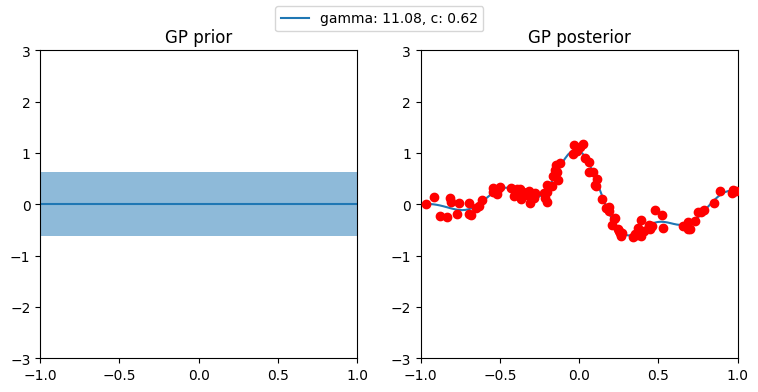

In [58]:
x = torch.linspace(-1, 1, 100)[:, None]

K = rbf_kernel(train_X, train_X, gamma=bestGamma, c=bestc) + torch.eye(x.shape[0])*bestSigma2
mu = torch.zeros_like(x)

fig, axs = plt.subplots(1, 2, figsize=(9, 4))

axs[0].plot(x, mu)
axs[0].fill_between(x.flatten(), mu.flatten()-K.diag(), mu.flatten()+K.diag(), alpha=0.5)
axs[0].set_xlim([-1, 1])
axs[0].set_ylim([-3, 3])
axs[0].set_title('GP prior')

def posterior_pred(x, xt, yt, gamma=10.0, c=1.0, s2 = bestSigma2):
    Kxxt = rbf_kernel(x, xt, gamma, c)
    Kxt = rbf_kernel(xt, xt, gamma, c) + torch.eye(xt.shape[0])*s2
    Kinv = torch.linalg.inv(Kxt)
    Kxx = rbf_kernel(x, x, gamma, c)

    mu = Kxxt @ Kinv @ yt
    cov = Kxx - Kxxt @ Kinv @ Kxxt.T
    return mu, cov

post_mu, post_cov = posterior_pred(x, torch.tensor(train_X, dtype=torch.float32).clone().detach(),
                                   torch.tensor(train_y, dtype=torch.float32).clone().detach(),
                                   bestGamma, bestc, bestSigma2)

axs[1].plot(x, post_mu)
axs[1].fill_between(x.flatten(), post_mu.flatten()-post_cov.diag(), post_mu.flatten()+post_cov.diag(), alpha=0.5)
axs[1].scatter(train_X, train_y, color='red', zorder=5)

axs[1].set_xlim([-1, 1])
axs[1].set_ylim([-3, 3])
axs[1].set_title('GP posterior')

# adicionamos a legenda com valores de 'gamma' e 'c'
fig.legend(['gamma: {:.2f}, c: {:.2f}'.format(bestGamma, bestc)], loc='upper center')

plt.show()

In [60]:
K = rbf_kernel(test_X, test_X, gamma=bestGamma, c=bestc)
LogMarginalLikelihood = -0.5*torch.logdet(K + (bestSigma2*torch.eye(len(test_X)))) - 0.5*(test_y.T @ torch.inverse(K + (bestSigma2*torch.eye(len(test_X)))) @ test_y)
print(f'Log Likelihood: {LogMarginalLikelihood.item():.5f}')

meanTest, _ = posterior_pred(ensure_tensor(test_X), ensure_tensor(train_X), ensure_tensor(train_y), gamma, c, bestSigma2)
MSE = torch.mean((meanTest - ensure_tensor(test_y))**2)
print(f'MSE: {MSE:.5f}')

Log Likelihood: 872.25562
MSE: 0.00995


Obtivemos um valor alto de log-verossimilhança no teste, sugerindo que o modelo está conseguindo prever os dados de forma precisa. Além disso, temos um MSE baixo, logo a média preditiva do GP está muito próxima dos valores reais do conjunto de teste